In [21]:
import mlflow
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
import mlflow.xgboost
from sklearn.metrics import accuracy_score, recall_score, f1_score

# Set experiment name
mlflow.set_experiment("Customer Churn Prediction")

print("MLflow version:", mlflow.__version__)
print("Tracking URI:", mlflow.get_tracking_uri())


MLflow version: 3.10.1
Tracking URI: sqlite:///F:/AIML/customer-churn/mlflow.db


In [2]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
import pickle
import warnings
warnings.filterwarnings('ignore')

# Load cleaned data
df = pd.read_csv('data/cleaned_churn.csv')

print("Shape:", df.shape)
print("Churn distribution:")
print(df['Churn'].value_counts())

Shape: (7043, 31)
Churn distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [3]:
# Separate features and target
X = df.drop('Churn', axis=1)  
y = df['Churn'] 

In [4]:
# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Total rows:", len(df))
print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Total rows: 7043
Training rows: 5634
Testing rows: 1409


Random Forest


In [5]:
# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [6]:
# Predict on test data
rf_predictions = rf_model.predict(X_test)

In [7]:
# Check accuracy
rf_accuracy = accuracy_score(y_test, rf_predictions)
print("Random Forest Accuracy:", round(rf_accuracy * 100, 2), "%")

Random Forest Accuracy: 79.49 %


XGBoost

In [8]:
# Train XGBoost
xgb_model = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [9]:
# Predict on test data
xgb_predictions = xgb_model.predict(X_test)

In [10]:
# Check accuracy
xgb_accuracy = accuracy_score(y_test, xgb_predictions)
print("XGBoost Accuracy:", round(xgb_accuracy * 100, 2), "%")

XGBoost Accuracy: 79.84 %


In [11]:
# XGBoost with class imbalance handling
xgb_model_v2 = XGBClassifier(
    n_estimators=100, 
    random_state=42, 
    eval_metric='logloss',
    scale_pos_weight=3  
)
xgb_model_v2.fit(X_train, y_train)

xgb_predictions_v2 = xgb_model_v2.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, xgb_predictions_v2) * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, xgb_predictions_v2))

Accuracy: 75.59 %

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.78      0.82      1036
           1       0.53      0.70      0.60       373

    accuracy                           0.76      1409
   macro avg       0.70      0.74      0.71      1409
weighted avg       0.79      0.76      0.77      1409



In [12]:
# Try different weights
for weight in [1, 2, 3, 4, 5]:
    model = XGBClassifier(
        n_estimators=100,
        random_state=42,
        eval_metric='logloss',
        scale_pos_weight=weight
    )
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = round(accuracy_score(y_test, preds) * 100, 2)
    report = classification_report(y_test, preds, output_dict=True)
    recall = round(report['1']['recall'] * 100, 2)
    print(f"Weight: {weight} | Accuracy: {acc}% | Recall(churners): {recall}%")

Weight: 1 | Accuracy: 79.84% | Recall(churners): 53.62%
Weight: 2 | Accuracy: 77.29% | Recall(churners): 64.34%
Weight: 3 | Accuracy: 75.59% | Recall(churners): 70.24%
Weight: 4 | Accuracy: 75.73% | Recall(churners): 71.58%
Weight: 5 | Accuracy: 74.59% | Recall(churners): 74.8%


In [13]:
# Final XGBoost model
final_model = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight=4
)
final_model.fit(X_train, y_train)
final_predictions = final_model.predict(X_test)

print("Final Model Accuracy:", round(accuracy_score(y_test, final_predictions) * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, final_predictions))

Final Model Accuracy: 75.73 %

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.77      0.82      1036
           1       0.53      0.72      0.61       373

    accuracy                           0.76      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.79      0.76      0.77      1409



In [14]:
# Save model to file
import pickle

with open('app/model.pkl', 'wb') as f:
    pickle.dump(final_model, f)

print("Model saved successfully!")

Model saved successfully!


In [15]:
# Log experiment with MLflow
with mlflow.start_run(run_name="XGBoost_weight4"):
    
    # Define parameters
    n_estimators = 100
    scale_pos_weight = 4
    
    # Train model
    model = XGBClassifier(
        n_estimators=n_estimators,
        random_state=42,
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight
    )
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)
    
    # Log parameters
    mlflow.log_param("n_estimators", n_estimators)
    mlflow.log_param("scale_pos_weight", scale_pos_weight)
    
    # Log metrics
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)
    
    # Log model
    mlflow.xgboost.log_model(model, "model")
    
    print("Run logged successfully!")
    print(f"Accuracy : {round(accuracy * 100, 2)}%")
    print(f"Recall   : {round(recall * 100, 2)}%")
    print(f"F1 Score : {round(f1 * 100, 2)}%")

2026/03/24 05:05:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Run logged successfully!
Accuracy : 75.73%
Recall   : 71.58%
F1 Score : 60.96%


In [16]:
# Log multiple experiments with different weights
weights = [1, 2, 3, 4, 5]

for weight in weights:
    with mlflow.start_run(run_name=f"XGBoost_weight{weight}"):
        
        # Train model
        model = XGBClassifier(
            n_estimators=100,
            random_state=42,
            eval_metric='logloss',
            scale_pos_weight=weight
        )
        model.fit(X_train, y_train)
        predictions = model.predict(X_test)
        
        # Calculate metrics
        accuracy = accuracy_score(y_test, predictions)
        recall = recall_score(y_test, predictions)
        f1 = f1_score(y_test, predictions)
        
        # Log parameters
        mlflow.log_param("n_estimators", 100)
        mlflow.log_param("scale_pos_weight", weight)
        
        # Log metrics
        mlflow.log_metric("accuracy", accuracy)
        mlflow.log_metric("recall", recall)
        mlflow.log_metric("f1_score", f1)
        
        # Log model
        mlflow.xgboost.log_model(model, "model")
        
        print(f"Weight: {weight} | Accuracy: {round(accuracy*100,2)}% | Recall: {round(recall*100,2)}%")

print("\n All experiments logged!")

2026/03/24 05:05:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Weight: 1 | Accuracy: 79.84% | Recall: 53.62%


2026/03/24 05:05:35 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Weight: 2 | Accuracy: 77.29% | Recall: 64.34%


2026/03/24 05:05:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Weight: 3 | Accuracy: 75.59% | Recall: 70.24%


2026/03/24 05:05:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Weight: 4 | Accuracy: 75.73% | Recall: 71.58%


2026/03/24 05:06:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Weight: 5 | Accuracy: 74.59% | Recall: 74.8%

 All experiments logged!


In [17]:
with open('app/model.pkl', 'rb') as f:
    final_model = pickle.load(f)

print(" Everything loaded successfully!")

 Everything loaded successfully!


In [19]:
# Initialize SHAP explainer
explainer = shap.TreeExplainer(final_model)

# Calculate SHAP values for test data
shap_values = explainer.shap_values(X_test)

print("SHAP values shape:", shap_values.shape)
print(" SHAP explainer ready!")

SHAP values shape: (1409, 30)
 SHAP explainer ready!


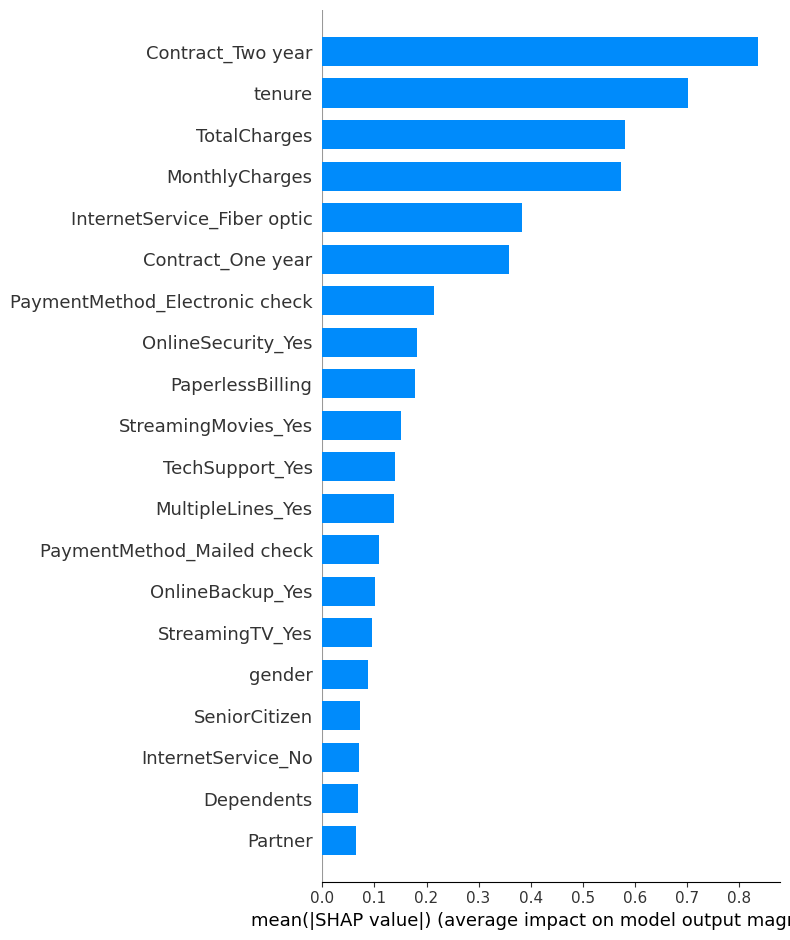

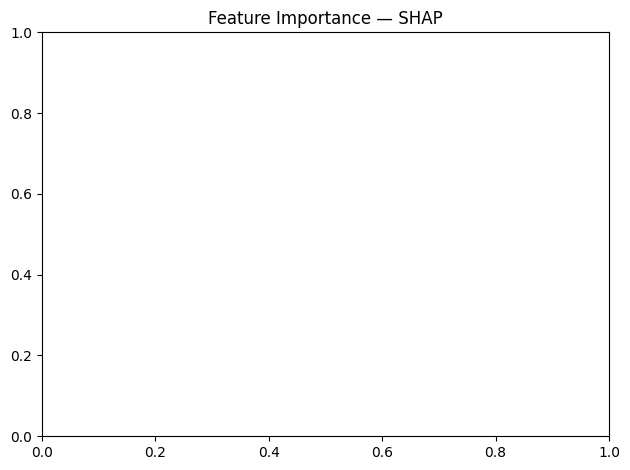

In [22]:
# Summary plot 
plt.figure()
shap.summary_plot(shap_values, X_test, plot_type="bar")
plt.title("Feature Importance — SHAP")
plt.tight_layout()
plt.show()

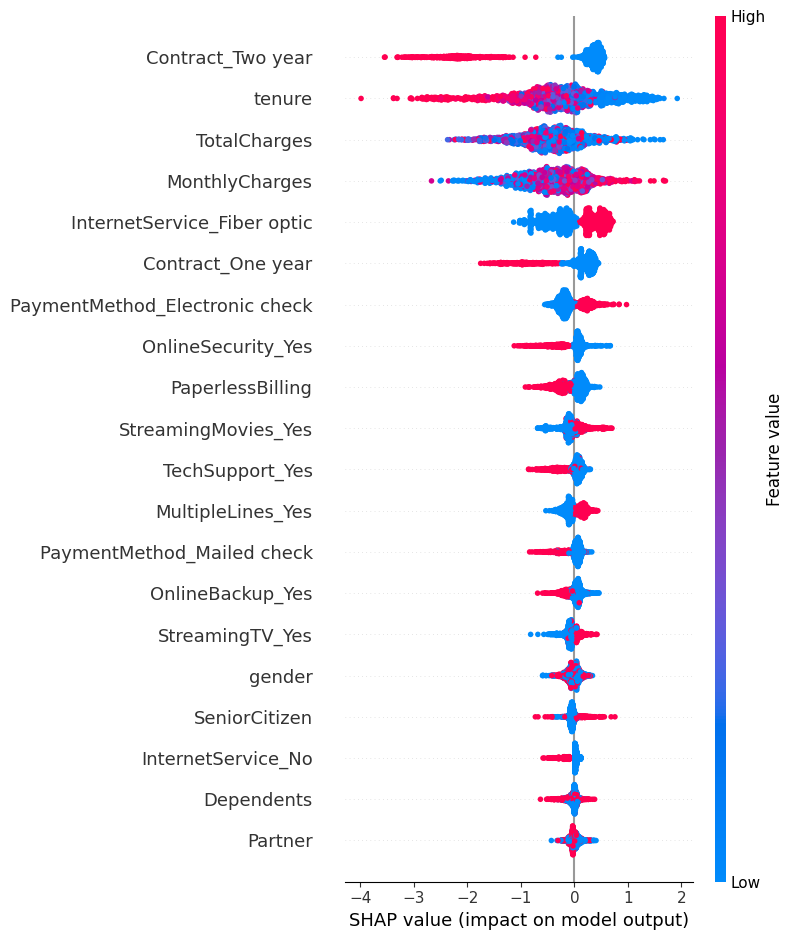

<Figure size 640x480 with 0 Axes>

In [23]:
# Detailed summary plot
plt.figure()
shap.summary_plot(shap_values, X_test)
plt.tight_layout()
plt.show()

Actual Churn: 0
Predicted Churn: 0


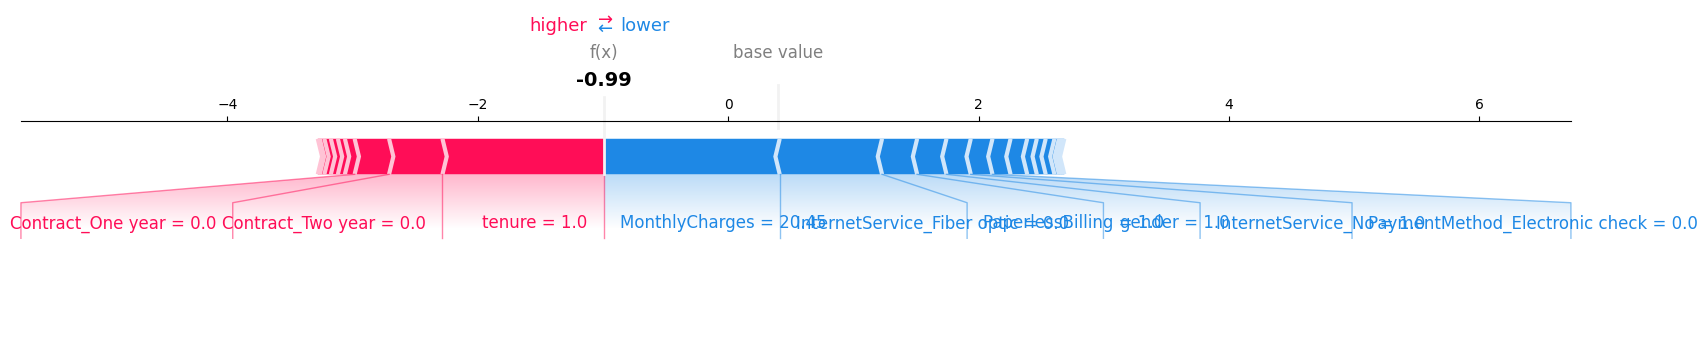

<Figure size 640x480 with 0 Axes>

In [24]:
i = 10 

print("Actual Churn:", y_test.iloc[i])
print("Predicted Churn:", final_model.predict(X_test)[i])

# Force plot for single customer
shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values[i],
    X_test.iloc[i],
    matplotlib=True
)
plt.tight_layout()
plt.show()